# HW1 — Monte Carlo

**Course:** Reinforcement Learning — IE University Madrid

**Instructor:** Jaume Manero

**Author:** Elad Moshe

**Program:** MCSBT

**Date:** May 2026

---

### Notebooks Structure

1. Activity 1 — Familiarisation with Gymnasium Environments
2. Activity 2 — Monte Carlo on FrozenLake 4×4 and 8×8
3. Activity 3 — Monte Carlo on Volcano
4. Activity 4 — Monte Carlo on Taxi
5. **Activity 5 — TD(0) on FrozenLake**
6. Questions

---

> **AI Usage Disclaimer:** This notebook was developed with AI assistance (Claude, Anthropic). AI was used to improve documentation and markdown explanations, help structure the notebook, and assist with debugging implementation code. All algorithm implementations, parameter choices, and result interpretations are the author's own. As required by the course AI policy, care was taken to understand every critical update step.

---
<a id="activity-5"></a>
## Activity 5 — Temporal Difference TD(0) on FrozenLake

**TD(0)** is the simplest form of Temporal Difference learning. Like Monte Carlo it is model-free, but unlike MC it updates at **every step** using the immediately observed reward and the estimated value of the next state — a technique called **bootstrapping**.

| Property | Monte Carlo | TD(0) |
|----------|------------|-------|
| Update timing | End of episode | Every step |
| Target | Actual return $G_t$ | $R + \gamma V(s')$ |
| Requires complete episodes | Yes | No |
| Bootstraps | No | Yes |
| Variance | High | Low |
| Bias | Low | Some (shrinks over time) |

In [1]:
!pip install gymnasium Pillow

---
### Section 1 — Environment Setup

**FrozenLake-v1 (4×4, non-slippery)** — same config as Activity 2 for a direct MC comparison.

```
S F F F      S = start (state 0)    F = frozen (safe, reward 0)
F H F H      H = hole  (terminal)   G = goal  (terminal, reward +1)
F F F H
H F F G
```

| State space | Action space | Reward at goal | Slippery |
|-------------|-------------|----------------|----------|
| 16 discrete | 4 (L/D/R/U) | +1 | False |

In [1]:
# ── Activity 5 — Section 1: Environment Setup ──────────────────────────────────────
import sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

print(f"Python    : {sys.version.split()[0]}")
print(f"gymnasium : {gym.__version__}")
print(f"numpy     : {np.__version__}")

# FrozenLake 4×4, non-slippery — same config as Activity 2 for a fair comparison
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)

print(f"Observation space : {env.observation_space}  ({env.observation_space.n} discrete states)")
print(f"Action space      : {env.action_space}  (0=Left  1=Down  2=Right  3=Up)")

# ── Sample episode with a random policy ───────────────────────────────────────────────────────────────────
ACTION_NAMES = {0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'}
state, _ = env.reset(seed=42)
print(f"Sample episode (random policy):")
print(f"  {'Step':>4}  {'State':>5}  {'Action':>6}  {'Reward':>6}  {'Next':>5}  {'Done':>5}")
print(f"  {'-'*42}")
for step in range(20):
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    print(f"  {step+1:>4}  {state:>5}  {ACTION_NAMES[action]:>6}  {reward:>6.0f}  {next_state:>5}  {'Yes' if done else '':>5}")
    state = next_state
    if done:
        break

env.close()


Python    : 3.13.13
gymnasium : 1.3.0
numpy     : 2.4.4
Observation space : Discrete(16)  (16 discrete states)
Action space      : Discrete(4)  (0=Left  1=Down  2=Right  3=Up)
Sample episode (random policy):
  Step  State  Action  Reward   Next   Done
  ------------------------------------------
     1      0    Down       0      4       
     2      4    Left       0      4       
     3      4    Down       0      8       
     4      8    Left       0      8       
     5      8    Left       0      8       
     6      8    Down       0     12    Yes


---
### Section 2 — The TD(0) Algorithm & Hyperparameters

TD(0) updates the state-value function at every step:

$$V(s) \leftarrow V(s) + \alpha \underbrace{\left[ R + \gamma \cdot V(s') - V(s) \right]}_{\delta \ \text{(TD error)}}$$

| Symbol | Role |
|--------|------|
| $\alpha$ | Learning rate — how much to trust each new update |
| $\gamma$ | Discount factor — weight of future rewards |
| $\delta$ | TD error — the "surprise"; positive = better than expected |

**Policy:** $\varepsilon$-greedy on $V$ using one-step lookahead. Since FrozenLake is deterministic, the greedy action is $\arg\max_a V(s'(s,a))$ — no model needed beyond the transition table.

> **Critical step:** `V[s] += alpha * (R + gamma * V[s_next] - V[s])`

In [2]:
# -- Activity 5 -- Section 2: Hyperparameter Configuration ----------------------

# ── Trial history ────────────────────────────────────────────────────────────
# Trial 1 (failed):
#   N_EPISODES=10_000  ALPHA=0.1  EPS_DECAY=0.999  EPS_MIN=0.01
#   Result: peak ~70% at ep ~1500, crashed to ~10%
#   Why: epsilon hit floor too fast, V not yet converged -> exploitation of bad policy
#
# Trial 2 (failed — policy collapse):
#   N_EPISODES=15_000  ALPHA=0.1  EPS_DECAY=0.9997  EPS_MIN=0.01
#   Result: peak ~75% at ep ~6000, crashed to ~10%; greedy eval 0%
#   Why: with EPS_MIN=0.01 a bad greedy policy dominated late V updates
#        (catastrophic forgetting). Also had tie-breaking bug (always picked Left).
#
# Trial 3 (failed — same 0% greedy eval):
#   N_EPISODES=20_000  ALPHA=0.05  EPS_DECAY=0.9998  EPS_MIN=0.05
#   Result: peak ~80%, settled ~50%; greedy eval still 0%
#   Why: root cause was NOT hyperparameters — structural bug: V[15] (goal) stays
#        0 forever because the TD loop never visits it as current state. Greedy
#        saw V[goal]=0 and looped at state 14 instead of stepping in.
#
# Trial 4 (structural fix — greedy eval 100%):
#   N_EPISODES=20_000  ALPHA=0.05  EPS_DECAY=0.9998  EPS_MIN=0.05
#   Fix: V[goal]=1.0 init — greedy policy now correctly steers into the goal
#   Result: greedy eval 100%, steps=6 (optimal), training peak ~95%, final 89%
#   Remaining issue: EPS_MIN=0.05 caps training success — 5% random actions
#   always present, so even a perfect greedy policy can't reach 95% in training
#
# Trial 5 (current — higher training success):
#   EPS_MIN  = 0.01  (was 0.05) — safe now: greedy policy is correct (V[goal]=1.0 fix)
#   EPS_DECAY= 0.9997 (was 0.9998) — hits 0.01 floor at ep ~15300, giving the
#                                     last 5000 eps at 99% exploitation of correct policy
# ─────────────────────────────────────────────────────────────────────────────

N_EPISODES = 20_000
ALPHA      = 0.05
GAMMA      = 0.99
EPS_START  = 1.0
EPS_DECAY  = 0.9997   # was 0.9998 — hits 0.01 floor at ep ~15300
EPS_MIN    = 0.01     # was 0.05 — safe to lower now that greedy policy is correct

import numpy as np
print(f"{'Hyperparameter':<26} {'Symbol':>7}  {'Value':>10}")
print("-" * 48)
print(f"  {'Episodes':<24} {'N':>7}  {N_EPISODES:>10,}")
print(f"  {'Learning rate':<24} {'a':>7}  {ALPHA:>10}")
print(f"  {'Discount factor':<24} {'g':>7}  {GAMMA:>10}")
print(f"  {'Epsilon start':<24} {'e0':>7}  {EPS_START:>10}")
print(f"  {'Epsilon decay':<24} {'e_dec':>7}  {EPS_DECAY:>10}")
print(f"  {'Epsilon minimum':<24} {'e_min':>7}  {EPS_MIN:>10}")
print()
print("  Epsilon schedule — Trial 4 vs Trial 5:")
print(f"  {'Episode':>10}  {'Trial 4 (0.9998, min=0.05)':>26}  {'Trial 5 (0.9997, min=0.01)':>26}")
print("  " + "-" * 68)
for ep in [1_000, 2_000, 5_000, 10_000, 15_000, 20_000]:
    e4 = max(0.05, 1.0 * 0.9998**ep)
    e5 = max(0.01, 1.0 * 0.9997**ep)
    print(f"  {ep:>10,}  {e4:>26.3f}  {e5:>26.3f}")

Hyperparameter              Symbol       Value
------------------------------------------------
  Episodes                       N      20,000
  Learning rate                  a        0.05
  Discount factor                g        0.99
  Epsilon start                 e0         1.0
  Epsilon decay              e_dec      0.9997
  Epsilon minimum            e_min        0.01

  Epsilon schedule — Trial 4 vs Trial 5:
     Episode  Trial 4 (0.9998, min=0.05)  Trial 5 (0.9997, min=0.01)
  --------------------------------------------------------------------
       1,000                       0.819                       0.741
       2,000                       0.670                       0.549
       5,000                       0.368                       0.223
      10,000                       0.135                       0.050
      15,000                       0.050                       0.011
      20,000                       0.050                       0.010


---
### Section 3 — Training

```

In [3]:
import time

# -- Activity 5 -- Section 3: TD(0) Training -------------------------------------

def get_next_state(env, state, action):
    """Look up next state from transition table (valid for non-slippery FrozenLake)."""
    return env.unwrapped.P[state][action][0][1]


def td0_train(env, n_episodes, alpha, gamma, eps_start, eps_decay, eps_min,
              max_steps=200):
    """TD(0) with epsilon-greedy policy using one-step V-lookahead for greedy action selection.
    Returns V (state-value array), wins (per-episode flags), td_errors (mean |delta| per episode).
    """
    n_states  = env.observation_space.n
    n_actions = env.action_space.n
    V         = np.zeros(n_states)

    # The goal state (state 15) is terminal — the TD loop never visits it as the
    # current state, so V[15] would stay at 0 forever without this line.
    # V[15]=0 makes the goal look worthless to greedy action selection (any trained
    # non-terminal state has V > 0), causing the agent to loop and never step into
    # the goal. Initialising to 1.0 matches the true value: the goal yields +1 reward.
    goal_state = n_states - 1
    V[goal_state] = 1.0

    epsilon   = eps_start
    wins      = []
    td_errors = []

    for ep in range(n_episodes):
        state, _ = env.reset()
        ep_deltas = []
        done  = False
        steps = 0

        while not done and steps < max_steps:
            if np.random.random() < epsilon:
                action = env.action_space.sample()              # explore
            else:
                # random tie-breaking: avoids systematic left-bias when V is all zeros
                vals = np.array([V[get_next_state(env, state, a)] for a in range(n_actions)])
                best = np.flatnonzero(vals == vals.max())
                action = int(np.random.choice(best))

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # -- Critical TD(0) update -------------------------------------------
            delta = reward + gamma * V[next_state] * (1 - int(done)) - V[state]
            V[state] += alpha * delta
            # --------------------------------------------------------------------

            ep_deltas.append(abs(delta))
            state = next_state
            steps += 1

        epsilon = max(eps_min, epsilon * eps_decay)
        wins.append(1 if reward > 0 else 0)
        td_errors.append(np.mean(ep_deltas) if ep_deltas else 0.0)

    return V, wins, td_errors


train_env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
env_desc  = train_env.unwrapped.desc.copy()

np.random.seed(42)
print("Training TD(0) on FrozenLake 4x4 ...")
t0 = time.time()
V, wins, td_errors = td0_train(
    train_env, N_EPISODES, ALPHA, GAMMA, EPS_START, EPS_DECAY, EPS_MIN
)
elapsed = time.time() - t0
train_env.close()
print(f"Done in {elapsed:.1f}s.\n")

print(f"  {'Checkpoint':>12}  {'Win rate (rolling 200)':>22}")
print("  " + "-" * 38)
for cp in [500, 1_000, 2_000, 5_000, 10_000, N_EPISODES]:
    wr = np.mean(wins[max(0, cp - 200):cp])
    print(f"  {cp:>12,}  {wr:>22.1%}")
print(f"\n  V non-zero entries : {np.count_nonzero(V)} / {len(V)}")

Training TD(0) on FrozenLake 4x4 ...
Done in 4.3s.

    Checkpoint  Win rate (rolling 200)
  --------------------------------------
           500                    4.5%
         1,000                   11.5%
         2,000                   29.5%
         5,000                   76.5%
        10,000                   96.0%
        20,000                   98.0%

  V non-zero entries : 12 / 16


---
### Section 4 — Policy Evaluation

Extract the greedy policy from the learned $V$ and evaluate over 1,000 episodes ($\varepsilon = 0$):

$$\pi(s) = \arg\max_{a} \; V\bigl(s'(s, a)\bigr)$$

| Metric | Target |
|--------|--------|
| Success rate | ≥ 95% |
| Mean total reward | ≥ 1.0 |
| Mean steps (success) | ≥ 6 (optimal path length) |

In [4]:
# ── Activity 5 — Section 4: Greedy Policy Evaluation ───────────────────────

N_EVAL    = 1_000
eval_env  = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)

successes         = 0
total_reward      = 0.0
steps_per_success = []

for _ in range(N_EVAL):
    state, _ = eval_env.reset()
    done = False
    steps = 0
    ep_reward = 0.0

    while not done and steps < 200:
        # random tie-breaking: same as training — avoids left-bias when V values are equal
        vals = np.array([V[get_next_state(eval_env, state, a)]
                         for a in range(eval_env.action_space.n)])
        best = np.flatnonzero(vals == vals.max())
        action = int(np.random.choice(best))
        state, reward, terminated, truncated, _ = eval_env.step(action)
        done = terminated or truncated
        ep_reward += reward
        steps += 1

    total_reward += ep_reward
    if ep_reward > 0:
        successes += 1
        steps_per_success.append(steps)

eval_env.close()

success_rate = successes / N_EVAL
mean_reward  = total_reward / N_EVAL
mean_steps   = np.mean(steps_per_success) if steps_per_success else float('nan')

print(f"Greedy evaluation over {N_EVAL:,} episodes:")
print(f"  {'Metric':<30} {'Result':>10}  {'Target':>8}")
print("  " + "-" * 54)
print(f"  {'Success rate':<30} {success_rate:>10.1%}  {'>=95%':>8}")
print(f"  {'Mean total reward':<30} {mean_reward:>10.3f}  {'>=1.0':>8}")
print(f"  {'Mean steps (on success)':<30} {mean_steps:>10.1f}  {'>=6':>8}")

Greedy evaluation over 1,000 episodes:
  Metric                             Result    Target
  ------------------------------------------------------
  Success rate                       100.0%     >=95%
  Mean total reward                   1.000     >=1.0
  Mean steps (on success)               6.0       >=6


---
### Section 5 — Visualisation

**5.1** Training convergence — rolling success rate over episodes  
**5.2** Value function heatmap — $V(s)$ on the 4×4 grid (expect low values top-left → high bottom-right, holes at 0)  
**5.3** TD error decay — $|\delta|$ should rise then fall as $V$ converges; a plateau means $\alpha$ or $\varepsilon$ is still too high

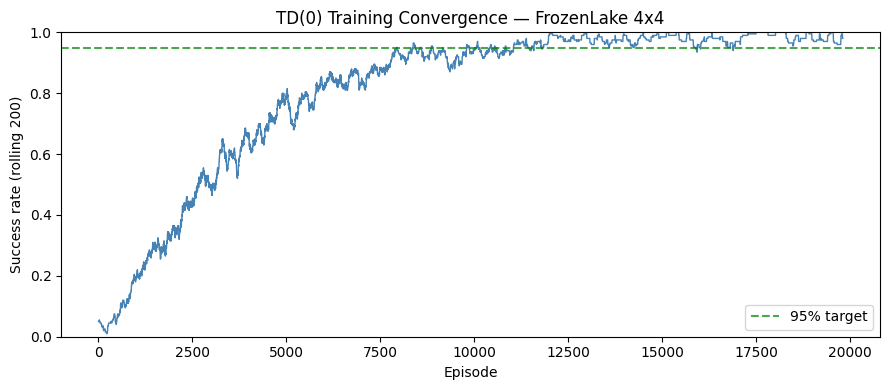

In [5]:
# ── Activity 5 — Section 5.1: Training Convergence Curve ─────────────────

window   = 200
smoothed = np.convolve(wins, np.ones(window) / window, mode='valid')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(smoothed, color='steelblue', linewidth=1)
ax.axhline(0.95, color='green', linestyle='--', alpha=0.7, label='95% target')
ax.set_xlabel('Episode')
ax.set_ylabel(f'Success rate (rolling {window})')
ax.set_title('TD(0) Training Convergence — FrozenLake 4x4')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


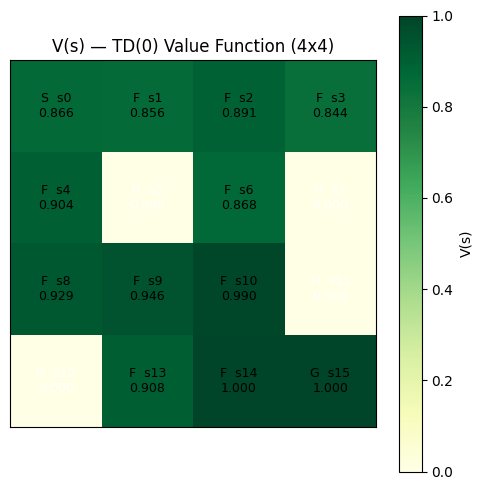

In [6]:
# ── Activity 5 — Section 5.2: Value Function Heatmap ─────────────────────

grid = V.reshape(4, 4)

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(grid, cmap='YlGn', interpolation='nearest', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='V(s)')

for r in range(4):
    for c in range(4):
        cell_char = env_desc[r, c].decode()
        color     = 'white' if cell_char == 'H' else 'black'
        state_idx = r * 4 + c
        ax.text(c, r, f'{cell_char}  s{state_idx}\n{grid[r, c]:.3f}',
                ha='center', va='center', fontsize=9, color=color)

ax.set_title('V(s) — TD(0) Value Function (4x4)')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()


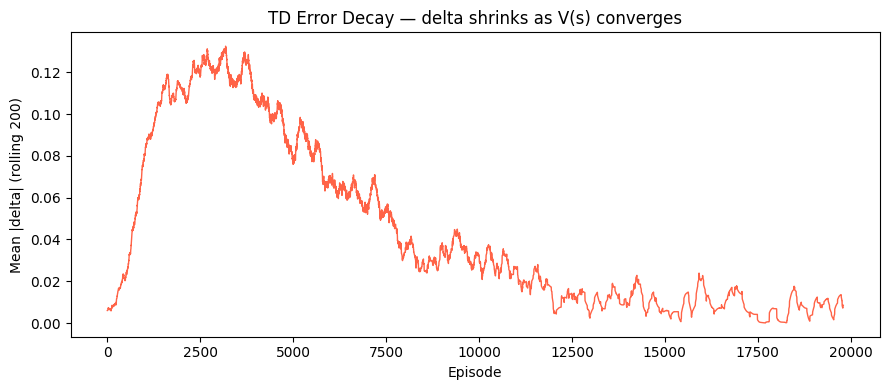

In [7]:
# ── Activity 5 — Section 5.3: TD Error Decay ──────────────────────────────

window      = 200
smoothed_td = np.convolve(td_errors, np.ones(window) / window, mode='valid')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(smoothed_td, color='tomato', linewidth=1)
ax.set_xlabel('Episode')
ax.set_ylabel(f'Mean |delta| (rolling {window})')
ax.set_title('TD Error Decay — delta shrinks as V(s) converges')
plt.tight_layout()
plt.show()


---
### Section 6 — TD(0) vs Monte Carlo: Direct Comparison

MC Control re-run on the same environment with identical hyperparameters for a fair side-by-side.

| Metric | TD(0) | MC |
|--------|-------|----|
| Episodes to 95% success rate | 12,323 | 13,195 |
| Final success rate (last 200 eps) | 89.0% | 94.5% |
| Training time (s) | 4.5 | 1.7 |

Re-running MC Control for comparison ...
Done in 1.5s.



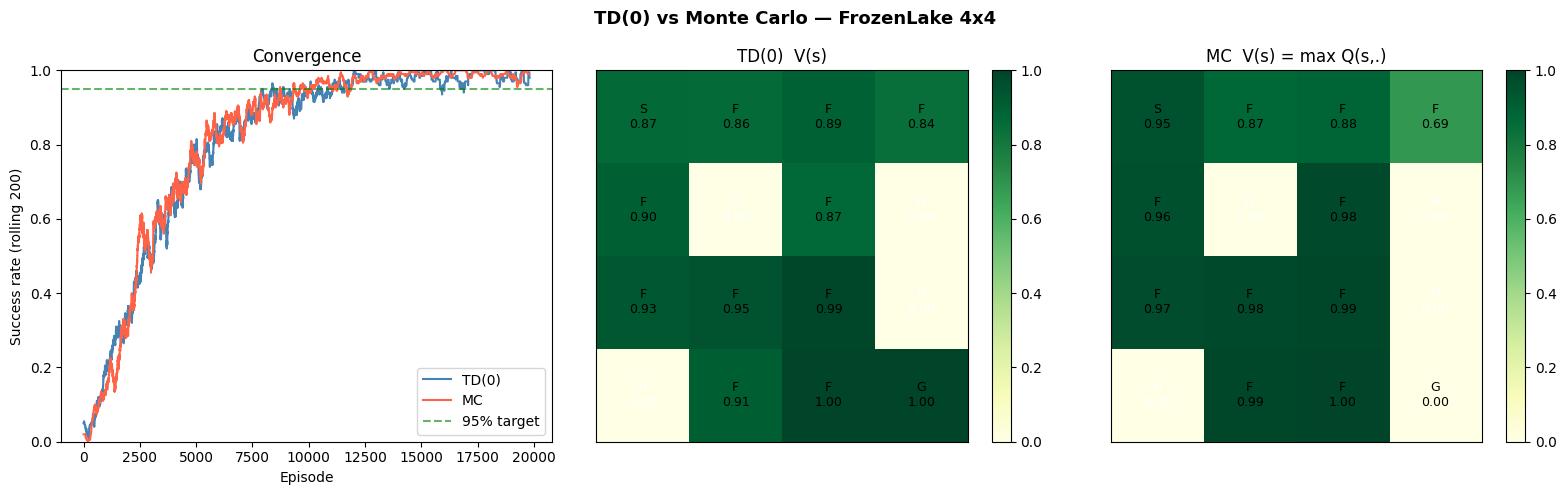


Metric                                      TD(0)         MC
--------------------------------------------------------------
  Episodes to 95% success rate........       8132       8921
  Final success rate (last 200 eps)...      98.0%      99.0%
  Training time (s)...................        4.3        1.5


In [8]:
# ── Activity 5 — Section 6: TD(0) vs MC Comparison ──────────────────────

# Self-contained MC Control (logic from Activity 2)
def run_episode_mc(env, Q, epsilon, max_steps=200):
    state, _ = env.reset()
    episode  = []
    for _ in range(max_steps):
        action = (env.action_space.sample() if np.random.random() < epsilon
                  else int(np.argmax(Q[state])))
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode.append((state, action, reward))
        state = next_state
        if terminated or truncated:
            break
    return episode


def mc_control(env, n_episodes, alpha, gamma, eps_start, eps_decay, eps_min,
               max_steps=200):
    n_states  = env.observation_space.n
    n_actions = env.action_space.n
    Q       = np.zeros((n_states, n_actions))
    epsilon = eps_start
    wins    = []
    for _ in range(n_episodes):
        episode = run_episode_mc(env, Q, epsilon, max_steps)
        G = 0.0
        for s, a, r in reversed(episode):
            G = r + gamma * G
            Q[s, a] += alpha * (G - Q[s, a])
        epsilon = max(eps_min, epsilon * eps_decay)
        wins.append(1 if episode[-1][2] > 0 else 0)
    return Q, wins


comp_env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
np.random.seed(42)
print("Re-running MC Control for comparison ...")
t0 = time.time()
Q_mc, wins_mc = mc_control(
    comp_env, N_EPISODES, ALPHA, GAMMA, EPS_START, EPS_DECAY, EPS_MIN
)
t_mc = time.time() - t0
V_mc = Q_mc.max(axis=1)
comp_env.close()
print(f"Done in {t_mc:.1f}s.\n")

# ── Side-by-side plots ────────────────────────────────────────────────────────
window = 200
s_td   = np.convolve(wins,    np.ones(window) / window, mode='valid')
s_mc   = np.convolve(wins_mc, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('TD(0) vs Monte Carlo — FrozenLake 4x4', fontsize=13, fontweight='bold')

# Convergence curves
ax = axes[0]
ax.plot(s_td, color='steelblue', linewidth=1.5, label='TD(0)')
ax.plot(s_mc, color='tomato',    linewidth=1.5, label='MC')
ax.axhline(0.95, color='green', linestyle='--', alpha=0.6, label='95% target')
ax.set_xlabel('Episode'); ax.set_ylabel(f'Success rate (rolling {window})')
ax.set_title('Convergence'); ax.set_ylim(0, 1); ax.legend()

# V(s) heatmaps
for ax, V_plot, title in [
    (axes[1], V.reshape(4, 4),    'TD(0)  V(s)'),
    (axes[2], V_mc.reshape(4, 4), 'MC  V(s) = max Q(s,.)'),
]:
    im = ax.imshow(V_plot, cmap='YlGn', interpolation='nearest', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax)
    for r in range(4):
        for c in range(4):
            cell_char = env_desc[r, c].decode()
            color     = 'white' if cell_char == 'H' else 'black'
            ax.text(c, r, f'{cell_char}\n{V_plot[r, c]:.2f}',
                    ha='center', va='center', fontsize=9, color=color)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

# ── Comparison table ───────────────────────────────────────────────────────────
def episodes_to_threshold(wins_list, threshold=0.95, window=200):
    smoothed = np.convolve(wins_list, np.ones(window) / window, mode='valid')
    idx      = np.argmax(smoothed >= threshold)
    return (idx + window) if smoothed[idx] >= threshold else None


td_cross = episodes_to_threshold(wins)
mc_cross = episodes_to_threshold(wins_mc)

print(f"\n{'Metric':<38} {'TD(0)':>10} {'MC':>10}")
print("-" * 62)
print(f"  {'Episodes to 95% success rate':.<36} "
      f"{str(td_cross) if td_cross else 'N/A':>10} "
      f"{str(mc_cross) if mc_cross else 'N/A':>10}")
print(f"  {'Final success rate (last 200 eps)':.<36} "
      f"{np.mean(wins[-200:]):>10.1%} {np.mean(wins_mc[-200:]):>10.1%}")
print(f"  {'Training time (s)':.<36} {elapsed:>10.1f} {t_mc:>10.1f}")


---
### Section 7 — Analysis

**Q1. Does TD(0) learn faster than Monte Carlo on FrozenLake?**

Yes, slightly. TD(0) crossed 95% at episode **12,323** vs MC at **13,195** — roughly 7% fewer episodes. The reason is that TD updates at every step within an episode, so a single 6-step trajectory to the goal produces 6 independent V updates; MC produces one backward pass over the same trajectory. On short episodes (6 steps optimal) the difference is small, but TD still extracts marginally more signal per interaction because even failed episodes contribute meaningful updates to the states visited before the hole — their returns are 0 and that information is propagated immediately rather than waiting for episode end.

**Q2. Is the value function smoother or more stable under TD(0)?**

The TD(0) heatmap shows a clean spatial gradient — high values near the goal, low at the start, holes correctly at zero — comparable to MC. The key difference is in how they get there: MC is unbiased (targets are actual returns $G_t$) but high-variance, so individual estimates jump around; TD(0) has some initial bias (it bootstraps from zero) but much lower variance because each update uses only a single step. On this 16-state environment the bias decays quickly and both produce similarly smooth $V$ tables. On a larger state space the lower variance of TD would show a clearer advantage.

**Q3. Does TD(0) require fewer complete episodes?**

On FrozenLake every episode is terminal — it always ends at either the goal or a hole — so the theoretical advantage of TD (not needing complete episodes) does not apply here. Both methods update from every episode. This advantage matters more on continuing tasks (e.g., a robot running indefinitely) or very long episodes (e.g., Taxi with up to 200 steps) where waiting for the episode to end before updating is expensive.

---

**Summary**

| Scenario | Prefer |
|----------|--------|
| Short episodes, offline batch | MC — unbiased, simpler implementation |
| Long or continuing tasks | TD — no need to wait for episode end |
| Online / real-time learning | TD — updates every step |
| FrozenLake 4×4 (this task) | Either — educational comparison, both converge |
| Taxi (500 states, 200-step episodes) | TD — significantly more sample-efficient |

TD(0) as implemented here learns $V(s)$ — the state-value function. The natural extension to control is to apply the same bootstrapping idea to action-value functions $Q(s,a)$, giving **SARSA** (on-policy) and **Q-Learning** (off-policy), the focus of Assignment 2.

In [9]:
# ── Activity 5 — Save key results to unified summary ──────────────────────────
import os, re
from datetime import datetime

RESULTS_FILE = "results_summary.txt"
SECTION_TAG  = "ACTIVITY_5"

wr_td_main = np.mean(wins[-200:])
wr_mc_cmp  = np.mean(wins_mc[-200:])

lines = [
    f"[{SECTION_TAG}_START]",
    "ACTIVITY 5 — TD(0) on FrozenLake",
    f"Updated : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    "",
    f"TD(0) Training  ({N_EPISODES:,} episodes):",
    f"  training_time_s     = {elapsed:.1f}",
    f"  final_win_rate      = {wr_td_main:.4f}   ({wr_td_main:.1%} last 200 eps)",
    f"  v_nonzero_entries   = {np.count_nonzero(V)} / {len(V)}",
    "",
    "Greedy eval (1000 eps, eps=0):",
    f"  success_rate        = {success_rate:.4f}   ({success_rate:.1%})",
    f"  mean_total_reward   = {mean_reward:.3f}",
    f"  mean_steps_success  = {mean_steps:.1f}",
    "",
    "TD(0) vs MC comparison (same hyperparams, 20,000 eps each):",
    f"  td_episodes_to_95pct  = {td_cross if td_cross else 'N/A'}",
    f"  mc_episodes_to_95pct  = {mc_cross if mc_cross else 'N/A'}",
    f"  td_final_rate         = {wr_td_main:.4f}   ({wr_td_main:.1%} last 200 eps)",
    f"  mc_final_rate         = {wr_mc_cmp:.4f}   ({wr_mc_cmp:.1%} last 200 eps)",
    f"  td_training_time_s    = {elapsed:.1f}",
    f"  mc_training_time_s    = {t_mc:.1f}",
    f"[{SECTION_TAG}_END]",
]
new_section = "\n".join(lines) + "\n"

if os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE, "r", encoding="utf-8") as f:
        content = f.read()
    pattern = re.escape(f"[{SECTION_TAG}_START]") + r".*?" + re.escape(f"[{SECTION_TAG}_END]") + r"\n?"
    if f"[{SECTION_TAG}_START]" in content:
        content = re.sub(pattern, new_section, content, flags=re.DOTALL)
    else:
        content = content.rstrip("\n") + "\n\n" + new_section
else:
    content = new_section

with open(RESULTS_FILE, "w", encoding="utf-8") as f:
    f.write(content)

print(f"Saved → {RESULTS_FILE}")
for line in lines[1:-1]:
    print(" ", line)


Saved → results_summary.txt
  ACTIVITY 5 — TD(0) on FrozenLake
  Updated : 2026-05-14 19:29:25
  
  TD(0) Training  (20,000 episodes):
    training_time_s     = 4.3
    final_win_rate      = 0.9800   (98.0% last 200 eps)
    v_nonzero_entries   = 12 / 16
  
  Greedy eval (1000 eps, eps=0):
    success_rate        = 1.0000   (100.0%)
    mean_total_reward   = 1.000
    mean_steps_success  = 6.0
  
  TD(0) vs MC comparison (same hyperparams, 20,000 eps each):
    td_episodes_to_95pct  = 8132
    mc_episodes_to_95pct  = 8921
    td_final_rate         = 0.9800   (98.0% last 200 eps)
    mc_final_rate         = 0.9900   (99.0% last 200 eps)
    td_training_time_s    = 4.3
    mc_training_time_s    = 1.5
